# Phase 2
# Model Evaluation & Comparison

## 1. Setup and Data Loading

### 1.1 Objective of This Section

This section loads the model prediction outputs provided by Member 2, standardizes their formats, and performs initial data validation before model evaluation.

The evaluation in this notebook focuses on:
- overall test-set performance
- confusion matrix and ROC analysis
- temporal accuracy
- spatial accuracy
- cross-validation results across time folds
- robustness and threshold sensitivity

In [61]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [62]:
data_dir = "data"

prediction_files = {
    "gradient_boosting": os.path.join(data_dir, "test_predictions_gradient_boosting.csv"),
    "hist_gradient_boosting": os.path.join(data_dir, "test_predictions_hist_gradient_boosting.csv"),
    "logistic_regression": os.path.join(data_dir, "test_predictions_logistic_regression.csv"),
    "random_forest": os.path.join(data_dir, "test_predictions_random_forest.csv"),
}

cv_file = os.path.join(data_dir, "time_fold_metrics.csv")

In [63]:
predictions = {}

for model_name, file_path in prediction_files.items():
    df = pd.read_csv(file_path)
    df["model_name"] = model_name
    predictions[model_name] = df

print("Loaded models:", list(predictions.keys()))
for model_name, df in predictions.items():
    print(f"{model_name}: {df.shape}")

Loaded models: ['gradient_boosting', 'hist_gradient_boosting', 'logistic_regression', 'random_forest']
gradient_boosting: (50347, 8)
hist_gradient_boosting: (50347, 8)
logistic_regression: (50347, 8)
random_forest: (50347, 8)


In [64]:
for model_name, df in predictions.items():
    print(f"\nModel: {model_name}")
    print(df.columns.tolist())


Model: gradient_boosting
['district', 'event_date', 'time_block', 'actual_label', 'predicted_probability', 'predicted_label', 'decision_threshold', 'model_name']

Model: hist_gradient_boosting
['district', 'event_date', 'time_block', 'actual_label', 'predicted_probability', 'predicted_label', 'decision_threshold', 'model_name']

Model: logistic_regression
['district', 'event_date', 'time_block', 'actual_label', 'predicted_probability', 'predicted_label', 'decision_threshold', 'model_name']

Model: random_forest
['district', 'event_date', 'time_block', 'actual_label', 'predicted_probability', 'predicted_label', 'decision_threshold', 'model_name']


In [65]:
required_columns = [
    "district",
    "event_date",
    "time_block",
    "actual_label",
    "predicted_probability",
    "predicted_label"
]

for model_name, df in predictions.items():
    missing_cols = [col for col in required_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"{model_name} is missing columns: {missing_cols}")
    
    df["event_date"] = pd.to_datetime(df["event_date"])
    df["district"] = df["district"].astype(str)
    df["time_block"] = df["time_block"].astype(str)
    df["actual_label"] = df["actual_label"].astype(int)
    df["predicted_label"] = df["predicted_label"].astype(int)
    df["predicted_probability"] = df["predicted_probability"].astype(float)

print("Column standardization completed.")

Column standardization completed.


In [66]:
for model_name, df in predictions.items():
    print(f"\n--- {model_name} ---")
    print("Shape:", df.shape)
    print("Missing values:")
    print(df[required_columns].isna().sum())
    print("Actual label distribution:")
    print(df["actual_label"].value_counts(dropna=False).sort_index())
    print("Predicted label distribution:")
    print(df["predicted_label"].value_counts(dropna=False).sort_index())


--- gradient_boosting ---
Shape: (50347, 8)
Missing values:
district                 0
event_date               0
time_block               0
actual_label             0
predicted_probability    0
predicted_label          0
dtype: int64
Actual label distribution:
actual_label
0    41252
1     9095
Name: count, dtype: int64
Predicted label distribution:
predicted_label
0    34786
1    15561
Name: count, dtype: int64

--- hist_gradient_boosting ---
Shape: (50347, 8)
Missing values:
district                 0
event_date               0
time_block               0
actual_label             0
predicted_probability    0
predicted_label          0
dtype: int64
Actual label distribution:
actual_label
0    41252
1     9095
Name: count, dtype: int64
Predicted label distribution:
predicted_label
0    36111
1    14236
Name: count, dtype: int64

--- logistic_regression ---
Shape: (50347, 8)
Missing values:
district                 0
event_date               0
time_block               0
actual_label   

In [67]:
reference_model = list(predictions.keys())[0]
reference_df = predictions[reference_model][["district", "event_date", "time_block", "actual_label"]].copy()

same_test_set = True

for model_name, df in predictions.items():
    compare_df = df[["district", "event_date", "time_block", "actual_label"]].copy()
    is_same = reference_df.equals(compare_df)
    print(f"{model_name} uses the same test set as {reference_model}: {is_same}")
    if not is_same:
        same_test_set = False

if not same_test_set:
    print("\nWarning: Not all models use the exact same test records.")
else:
    print("\nAll models use the same test set.")

gradient_boosting uses the same test set as gradient_boosting: True
hist_gradient_boosting uses the same test set as gradient_boosting: True
logistic_regression uses the same test set as gradient_boosting: True
random_forest uses the same test set as gradient_boosting: True

All models use the same test set.


In [68]:
all_predictions = pd.concat(predictions.values(), ignore_index=True)

print("Combined prediction table shape:", all_predictions.shape)
all_predictions.head()

Combined prediction table shape: (201388, 8)


,district,event_date,time_block,actual_label,predicted_probability,predicted_label,decision_threshold,model_name
0,1,2025-01-01,0,0,0.046187,0,0.25,gradient_boosting
1,1,2025-01-01,1,0,0.228168,0,0.25,gradient_boosting
2,1,2025-01-01,2,1,0.451455,1,0.25,gradient_boosting
3,1,2025-01-01,3,0,0.524994,1,0.25,gradient_boosting
4,1,2025-01-01,4,0,0.257464,1,0.25,gradient_boosting


In [69]:
time_fold_metrics = pd.read_csv(cv_file)

print("Time-fold metrics shape:", time_fold_metrics.shape)
time_fold_metrics.head()

Time-fold metrics shape: (66, 21)


,model,fold,train_end_date,valid_start_date,valid_end_date,train_rows,valid_rows,best_threshold,C,class_weight,fold_accuracy,fold_precision,fold_recall,fold_f1,fold_roc_auc,n_estimators,max_depth,min_samples_leaf,learning_rate,subsample,max_iter
0,gradient_boosting,1,2019-12-31,2020-01-01,2021-08-31,251988,84042,0.25,NaN,NaN,0.812558,0.370794,0.568466,0.448830,0.824265,150.0,2.0,NaN,0.03,0.8,NaN
1,gradient_boosting,1,2019-12-31,2020-01-01,2021-08-31,251988,84042,0.25,NaN,NaN,0.811249,0.370782,0.582381,0.453094,0.825935,150.0,2.0,NaN,0.05,0.8,NaN
2,gradient_boosting,1,2019-12-31,2020-01-01,2021-08-31,251988,84042,0.25,NaN,NaN,0.811594,0.370923,0.579544,0.452338,0.826389,250.0,2.0,NaN,0.03,0.8,NaN
3,gradient_boosting,1,2019-12-31,2020-01-01,2021-08-31,251988,84042,0.25,NaN,NaN,0.808893,0.367748,0.588762,0.452721,0.827457,250.0,2.0,NaN,0.05,0.8,NaN
4,gradient_boosting,2,2021-08-31,2021-09-01,2023-05-02,336030,84042,0.20,NaN,NaN,0.714940,0.362589,0.756008,0.490114,0.806594,150.0,2.0,NaN,0.03,0.8,NaN


In [70]:
print(time_fold_metrics.columns.tolist())

['model', 'fold', 'train_end_date', 'valid_start_date', 'valid_end_date', 'train_rows', 'valid_rows', 'best_threshold', 'C', 'class_weight', 'fold_accuracy', 'fold_precision', 'fold_recall', 'fold_f1', 'fold_roc_auc', 'n_estimators', 'max_depth', 'min_samples_leaf', 'learning_rate', 'subsample', 'max_iter']


### 1.2 Initial Data Validation Summary

At this stage, all model prediction files and time-fold metrics have been loaded and reviewed.

The following checks have been completed:
- required columns in prediction files were verified
- date and label formats were standardized
- missing values were inspected
- label distributions were reviewed
- test-set consistency across models was checked
- time-fold evaluation results were loaded for later cross-validation analysis

The combined prediction table created in this section will be used for all subsequent evaluation analyses.

## 2. Overall Model Performance on the Test Set

### 2.1 Objective of This Section

This section evaluates the overall performance of each model on the 2025 test set using standard classification metrics.

The main metrics reported are:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Because hotspot prediction is an imbalanced classification task, the discussion will focus primarily on precision, recall, F1-score, and ROC-AUC rather than accuracy alone.

In [71]:
def compute_classification_metrics(df):
    y_true = df["actual_label"]
    y_pred = df["predicted_label"]
    y_prob = df["predicted_probability"]
    
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "predicted_positive_rate": y_pred.mean(),
        "actual_positive_rate": y_true.mean()
    }

In [72]:
overall_metrics_list = []

for model_name, df in predictions.items():
    metrics = compute_classification_metrics(df)
    metrics["model_name"] = model_name
    overall_metrics_list.append(metrics)

overall_metrics = pd.DataFrame(overall_metrics_list)

overall_metrics = overall_metrics[
    [
        "model_name",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "predicted_positive_rate",
        "actual_positive_rate"
    ]
]

overall_metrics

,model_name,accuracy,precision,recall,f1,roc_auc,predicted_positive_rate,actual_positive_rate
0,gradient_boosting,0.762290,0.407686,0.697526,0.514601,0.822280,0.309075,0.180646
1,hist_gradient_boosting,0.783562,0.436710,0.683562,0.532939,0.833642,0.282758,0.180646
2,logistic_regression,0.772598,0.417865,0.658384,0.511249,0.821735,0.284625,0.180646
3,random_forest,0.772022,0.422089,0.709731,0.529359,0.832082,0.303752,0.180646


In [73]:
overall_metrics_sorted = overall_metrics.sort_values(
    by=["f1", "roc_auc"], ascending=False
).reset_index(drop=True)

overall_metrics_display = overall_metrics_sorted.copy()

for col in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "predicted_positive_rate",
    "actual_positive_rate"
]:
    overall_metrics_display[col] = overall_metrics_display[col].round(3)

overall_metrics_display

,model_name,accuracy,precision,recall,f1,roc_auc,predicted_positive_rate,actual_positive_rate
0,hist_gradient_boosting,0.784,0.437,0.684,0.533,0.834,0.283,0.181
1,random_forest,0.772,0.422,0.710,0.529,0.832,0.304,0.181
2,gradient_boosting,0.762,0.408,0.698,0.515,0.822,0.309,0.181
3,logistic_regression,0.773,0.418,0.658,0.511,0.822,0.285,0.181


In [74]:
best_accuracy_model = overall_metrics.loc[overall_metrics["accuracy"].idxmax(), "model_name"]
best_precision_model = overall_metrics.loc[overall_metrics["precision"].idxmax(), "model_name"]
best_recall_model = overall_metrics.loc[overall_metrics["recall"].idxmax(), "model_name"]
best_f1_model = overall_metrics.loc[overall_metrics["f1"].idxmax(), "model_name"]
best_auc_model = overall_metrics.loc[overall_metrics["roc_auc"].idxmax(), "model_name"]

print("Best Accuracy Model :", best_accuracy_model)
print("Best Precision Model:", best_precision_model)
print("Best Recall Model   :", best_recall_model)
print("Best F1 Model       :", best_f1_model)
print("Best ROC-AUC Model  :", best_auc_model)

Best Accuracy Model : hist_gradient_boosting
Best Precision Model: hist_gradient_boosting
Best Recall Model   : random_forest
Best F1 Model       : hist_gradient_boosting
Best ROC-AUC Model  : hist_gradient_boosting


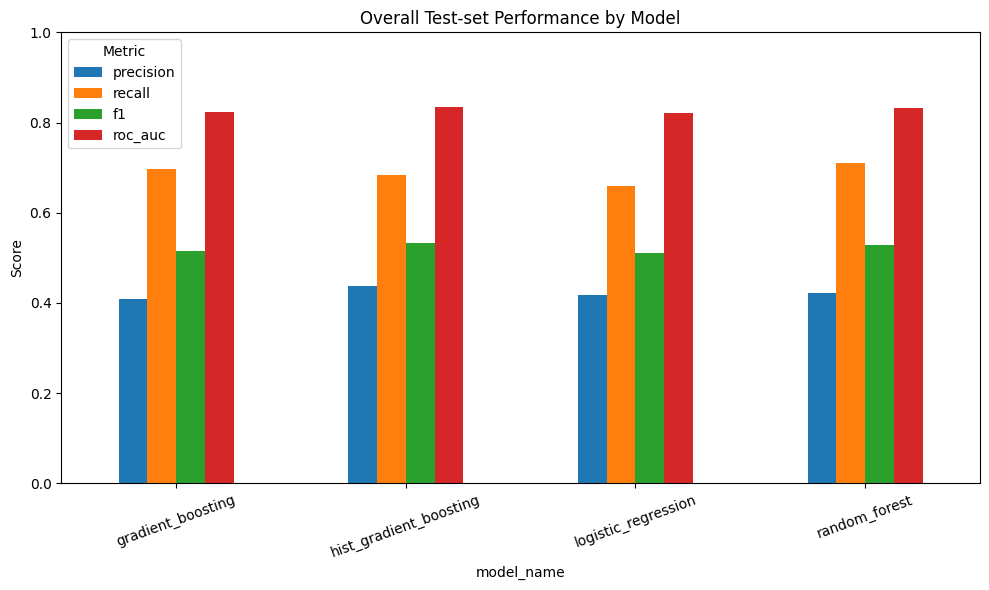

In [75]:
plot_df = overall_metrics.set_index("model_name")[["precision", "recall", "f1", "roc_auc"]]

ax = plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Overall Test-set Performance by Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### 2.2 Summary of Overall Test-set Performance

The overall results show that the four models exhibit different trade-offs between precision and recall.

At this stage, the key questions are:
- Which model achieves the highest F1-score?
- Which model provides the best recall for hotspot detection?
- Which model is more conservative and produces fewer positive hotspot predictions?
- Whether the model with the highest ROC-AUC is also the most practical choice for this task.

These findings will be further examined using confusion matrices, ROC curves, temporal evaluation, and spatial evaluation in the following sections.

## 3. Confusion Matrix and ROC Curve Analysis

### 3.1 Objective of This Section

This section examines model behavior in more detail using confusion matrices and ROC curves.

The confusion matrix helps identify:
- true positives
- true negatives
- false positives
- false negatives

The ROC curve helps compare the probability-ranking ability of each model across all possible thresholds.

This section is especially important for hotspot prediction because different models may achieve similar overall scores while making very different types of errors.

In [76]:
def plot_confusion_matrix_from_df(df, model_name, ax=None):
    y_true = df["actual_label"]
    y_pred = df["predicted_label"]
    
    cm = confusion_matrix(y_true, y_pred)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(f"Confusion Matrix: {model_name}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels([0, 1])
    ax.set_yticklabels([0, 1])

    # 在格子中间写数字
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    return cm

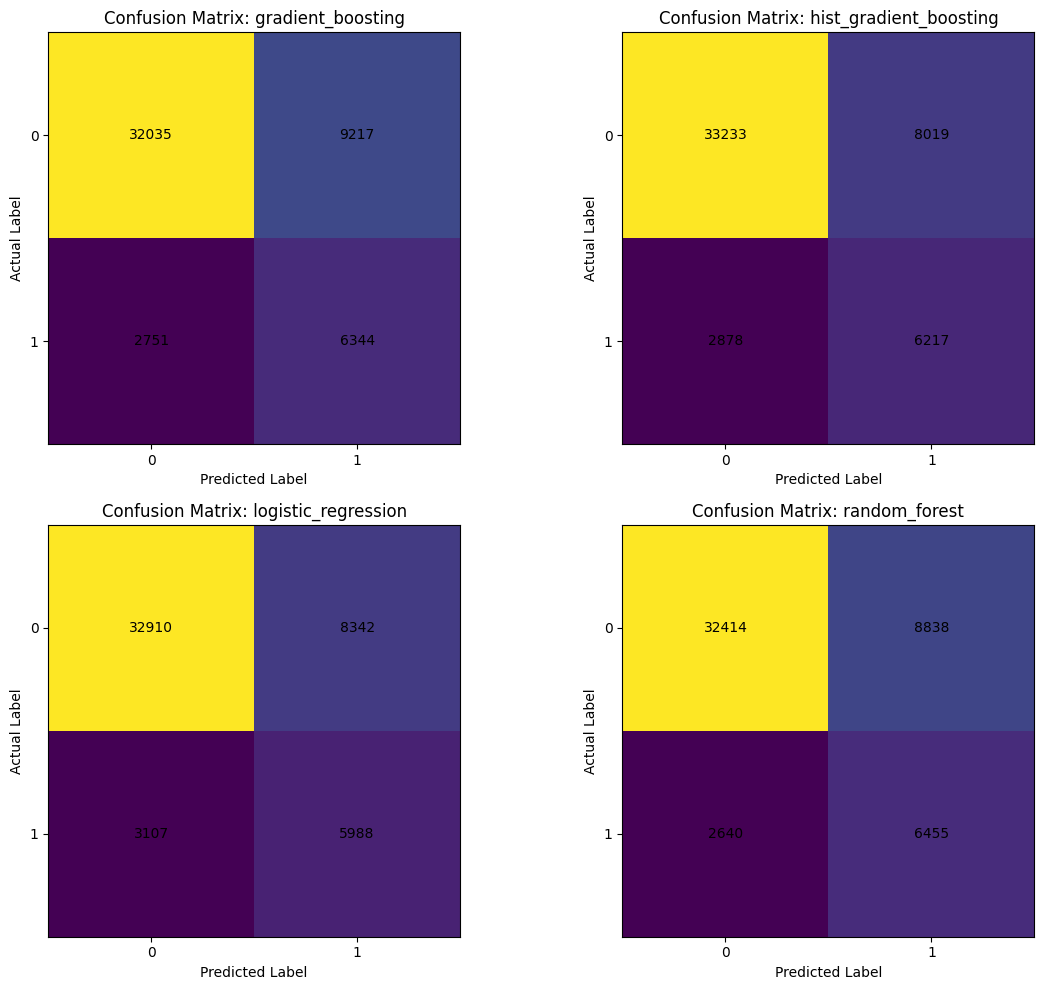

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

confusion_matrices = {}

for ax, (model_name, df) in zip(axes, predictions.items()):
    cm = plot_confusion_matrix_from_df(df, model_name, ax=ax)
    confusion_matrices[model_name] = cm

plt.tight_layout()
plt.show()

In [78]:
cm_summary = []

for model_name, cm in confusion_matrices.items():
    tn, fp, fn, tp = cm.ravel()
    cm_summary.append({
        "model_name": model_name,
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp
    })

cm_summary_df = pd.DataFrame(cm_summary)
cm_summary_df

,model_name,true_negative,false_positive,false_negative,true_positive
0,gradient_boosting,32035,9217,2751,6344
1,hist_gradient_boosting,33233,8019,2878,6217
2,logistic_regression,32910,8342,3107,5988
3,random_forest,32414,8838,2640,6455


In [79]:
cm_summary_rates = cm_summary_df.copy()

cm_summary_rates["false_positive_rate"] = (
    cm_summary_rates["false_positive"] /
    (cm_summary_rates["false_positive"] + cm_summary_rates["true_negative"])
)

cm_summary_rates["false_negative_rate"] = (
    cm_summary_rates["false_negative"] /
    (cm_summary_rates["false_negative"] + cm_summary_rates["true_positive"])
)

cm_summary_rates["true_positive_rate"] = (
    cm_summary_rates["true_positive"] /
    (cm_summary_rates["true_positive"] + cm_summary_rates["false_negative"])
)

cm_summary_rates["true_negative_rate"] = (
    cm_summary_rates["true_negative"] /
    (cm_summary_rates["true_negative"] + cm_summary_rates["false_positive"])
)

for col in [
    "false_positive_rate",
    "false_negative_rate",
    "true_positive_rate",
    "true_negative_rate"
]:
    cm_summary_rates[col] = cm_summary_rates[col].round(3)

cm_summary_rates

,model_name,true_negative,false_positive,false_negative,true_positive,false_positive_rate,false_negative_rate,true_positive_rate,true_negative_rate
0,gradient_boosting,32035,9217,2751,6344,0.223,0.302,0.698,0.777
1,hist_gradient_boosting,33233,8019,2878,6217,0.194,0.316,0.684,0.806
2,logistic_regression,32910,8342,3107,5988,0.202,0.342,0.658,0.798
3,random_forest,32414,8838,2640,6455,0.214,0.290,0.710,0.786


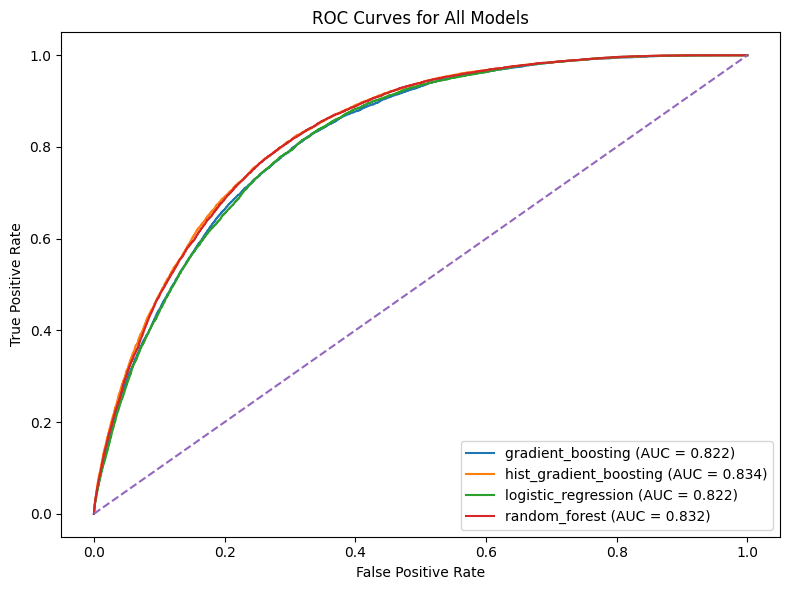

In [80]:
plt.figure(figsize=(8, 6))

for model_name, df in predictions.items():
    y_true = df["actual_label"]
    y_prob = df["predicted_probability"]
    
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)
    
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.tight_layout()
plt.show()

In [81]:
error_comparison = cm_summary_df[[
    "model_name",
    "false_positive",
    "false_negative",
    "true_positive",
    "true_negative"
]].copy()

error_comparison

,model_name,false_positive,false_negative,true_positive,true_negative
0,gradient_boosting,9217,2751,6344,32035
1,hist_gradient_boosting,8019,2878,6217,33233
2,logistic_regression,8342,3107,5988,32910
3,random_forest,8838,2640,6455,32414


### 3.2 Summary of Confusion Matrix and ROC Analysis

The confusion matrices show that the models differ substantially in how aggressively they classify hotspot cases.

In general:
- models with higher recall tend to produce more positive predictions and fewer false negatives
- models with higher precision tend to be more conservative and may miss more true hotspot cases

The ROC curves provide a threshold-independent view of model discrimination ability.  
However, for this hotspot prediction task, practical usefulness also depends on the balance between false negatives and false positives at the chosen decision threshold.

The confusion matrices reveal a clear difference in classification behavior across models.

Gradient Boosting and HistGradientBoosting are relatively conservative classifiers. They produce fewer false positives and achieve high true negative rates, but they also miss a large proportion of true hotspot cases. In particular, their false negative rates are substantially higher than those of Logistic Regression and Random Forest.

By contrast, Logistic Regression and Random Forest are much more aggressive in predicting hotspot cases. Both models achieve high true positive rates and substantially lower false negative rates, indicating better hotspot detection ability. However, this comes at the cost of a noticeably higher false positive rate.

The ROC curves show that all four models have broadly similar ranking ability, with HistGradientBoosting achieving the highest ROC-AUC and Random Forest performing closely behind. However, the confusion matrices demonstrate that a higher ROC-AUC does not automatically translate into better operational performance at the default threshold. For this hotspot prediction task, the balance between missed hotspots and false alerts is especially important, which makes Random Forest and Logistic Regression more practically attractive despite their lower precision.

## 4. Temporal Accuracy Evaluation

### 4.1 Objective of This Section

This section evaluates whether model performance remains stable across different time periods in the 2025 test set.

Because crime patterns may vary across months and seasons, temporal evaluation is important for assessing whether a model performs consistently over time rather than only achieving strong overall results.

The main questions addressed in this section are:
- Does model performance remain stable across months?
- Are there months in which performance drops noticeably?
- Which model shows the best temporal consistency?

In [82]:
temporal_df = all_predictions.copy()
temporal_df["year_month"] = temporal_df["event_date"].dt.to_period("M").astype(str)

temporal_df[["event_date", "year_month", "model_name"]].head()

,event_date,year_month,model_name
0,2025-01-01,2025-01,gradient_boosting
1,2025-01-01,2025-01,gradient_boosting
2,2025-01-01,2025-01,gradient_boosting
3,2025-01-01,2025-01,gradient_boosting
4,2025-01-01,2025-01,gradient_boosting


In [83]:
def compute_group_metrics(df):
    y_true = df["actual_label"]
    y_pred = df["predicted_label"]
    y_prob = df["predicted_probability"]
    
    return pd.Series({
        "n_samples": len(df),
        "positive_rate": y_true.mean(),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if y_true.nunique() > 1 else np.nan
    })

In [84]:
monthly_metrics = (
    temporal_df
    .groupby(["model_name", "year_month"])
    .apply(compute_group_metrics)
    .reset_index()
    .sort_values(["year_month", "model_name"])
)

monthly_metrics.head(12)

,model_name,year_month,n_samples,positive_rate,precision,recall,f1,roc_auc
0,gradient_boosting,2025-01,4278.0,0.139785,0.362755,0.625418,0.459177,0.815375
12,hist_gradient_boosting,2025-01,4278.0,0.139785,0.400000,0.615385,0.484848,0.831502
24,logistic_regression,2025-01,4278.0,0.139785,0.392279,0.526756,0.449679,0.818291
36,random_forest,2025-01,4278.0,0.139785,0.385947,0.633779,0.479747,0.829892
1,gradient_boosting,2025-02,3864.0,0.137681,0.353147,0.569549,0.435971,0.810602
13,hist_gradient_boosting,2025-02,3864.0,0.137681,0.370968,0.562030,0.446936,0.821530
25,logistic_regression,2025-02,3864.0,0.137681,0.364499,0.505639,0.423622,0.811359
37,random_forest,2025-02,3864.0,0.137681,0.366940,0.588346,0.451986,0.819791
2,gradient_boosting,2025-03,4278.0,0.166667,0.398698,0.687237,0.504634,0.829407
14,hist_gradient_boosting,2025-03,4278.0,0.166667,0.434545,0.670407,0.527303,0.839503


In [85]:
monthly_f1_table = monthly_metrics.pivot(
    index="year_month",
    columns="model_name",
    values="f1"
)

monthly_f1_table.round(3)

model_name,gradient_boosting,hist_gradient_boosting,logistic_regression,random_forest
year_month,,,,
2025-01,0.459,0.485,0.450,0.480
2025-02,0.436,0.447,0.424,0.452
2025-03,0.505,0.527,0.501,0.519
2025-04,0.530,0.541,0.524,0.543
2025-05,0.536,0.555,0.534,0.548
2025-06,0.551,0.566,0.540,0.564
2025-07,0.594,0.605,0.593,0.601
2025-08,0.539,0.556,0.538,0.559
2025-09,0.527,0.553,0.525,0.536


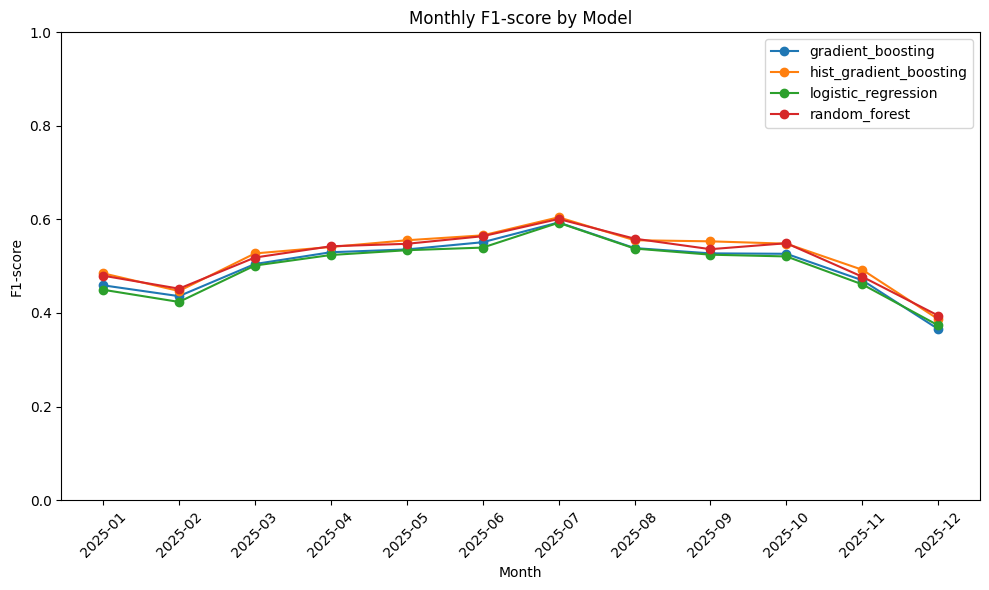

In [86]:
plt.figure(figsize=(10, 6))

for model_name in monthly_metrics["model_name"].unique():
    sub = monthly_metrics[monthly_metrics["model_name"] == model_name]
    plt.plot(sub["year_month"], sub["f1"], marker="o", label=model_name)

plt.title("Monthly F1-score by Model")
plt.xlabel("Month")
plt.ylabel("F1-score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

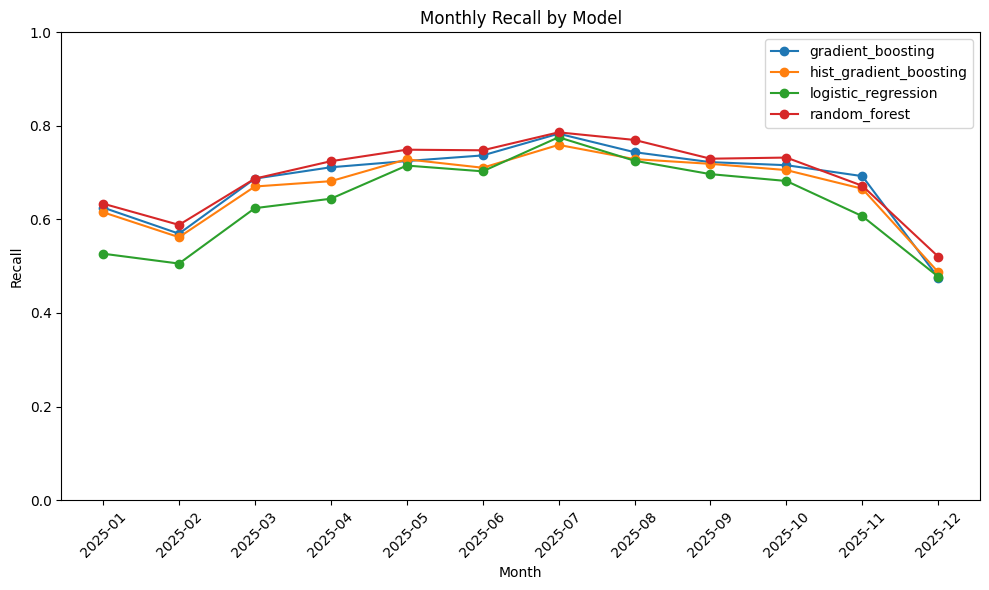

In [87]:
plt.figure(figsize=(10, 6))

for model_name in monthly_metrics["model_name"].unique():
    sub = monthly_metrics[monthly_metrics["model_name"] == model_name]
    plt.plot(sub["year_month"], sub["recall"], marker="o", label=model_name)

plt.title("Monthly Recall by Model")
plt.xlabel("Month")
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

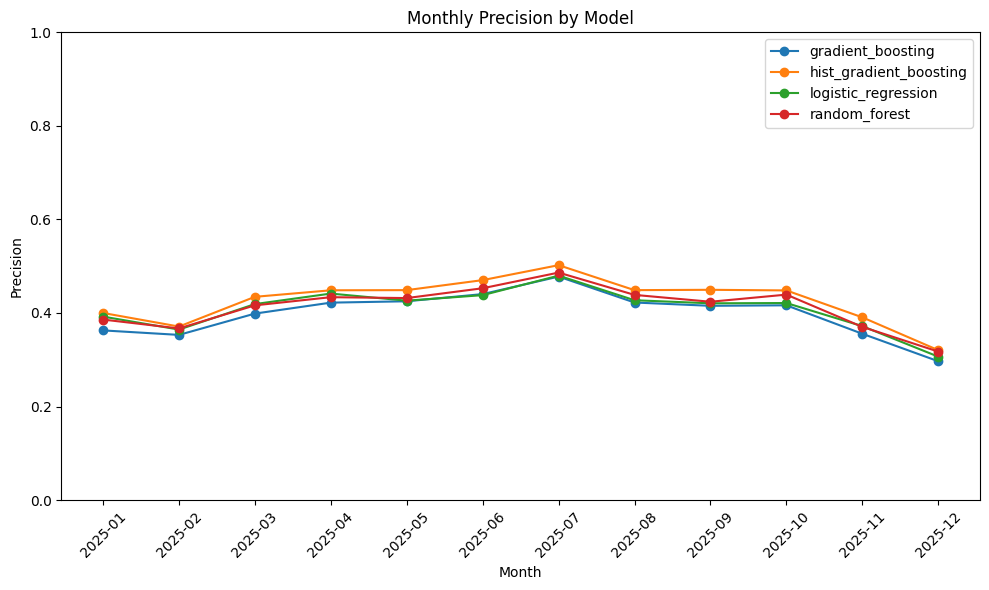

In [88]:
plt.figure(figsize=(10, 6))

for model_name in monthly_metrics["model_name"].unique():
    sub = monthly_metrics[monthly_metrics["model_name"] == model_name]
    plt.plot(sub["year_month"], sub["precision"], marker="o", label=model_name)

plt.title("Monthly Precision by Model")
plt.xlabel("Month")
plt.ylabel("Precision")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [89]:
temporal_summary = (
    monthly_metrics
    .groupby("model_name")[["precision", "recall", "f1", "roc_auc"]]
    .agg(["mean", "std"])
)

temporal_summary.round(3)

precision        recall            f1        roc_auc       
                            mean    std   mean    std   mean    std    mean    std
model_name                                                                        
gradient_boosting          0.399  0.049  0.682  0.086  0.503  0.061   0.817  0.010
hist_gradient_boosting     0.428  0.049  0.670  0.079  0.522  0.060   0.829  0.011
logistic_regression        0.409  0.045  0.640  0.095  0.499  0.061   0.816  0.011
random_forest              0.414  0.046  0.695  0.079  0.519  0.057   0.827  0.011

### 4.2 Summary of Temporal Accuracy Evaluation

This section compares monthly model performance to assess temporal consistency.

Particular attention is given to:
- whether the ranking of models remains similar across months
- whether any model shows large month-to-month fluctuation
- whether the overall best-performing model also remains stable over time

The temporal evaluation helps determine whether the selected model is robust to changing temporal patterns rather than performing well only in aggregate.

Monthly evaluation shows that the ranking of the four models remains broadly stable throughout the 2025 test period. In most months, Random Forest and Logistic Regression achieve the highest F1-scores, while HistGradientBoosting and Gradient Boosting remain consistently weaker in threshold-based classification performance.

All models exhibit a clear temporal pattern, with lower F1-scores in the early and late months of the year, and stronger performance around the middle of the year, especially near July. This suggests that the hotspot prediction task is affected by temporal variation in the underlying crime pattern rather than being perfectly stationary across the test period.

The temporal summary further shows that Random Forest achieves the highest mean monthly F1-score, while Logistic Regression provides a very competitive and slightly more stable baseline. In contrast, the boosting-based models show both lower average F1 and substantially larger month-to-month variation. Interestingly, ROC-AUC remains highly stable across months for all models, indicating that ranking ability is relatively consistent, whereas threshold-based operational performance varies more strongly over time.

Part of the month-to-month variation may also be influenced by changes in hotspot prevalence across the test period. Therefore, temporal fluctuation should be interpreted as a combination of model sensitivity and underlying variation in the class distribution.

## 5. Spatial Accuracy Evaluation

### 5.1 Objective of This Section

This section evaluates whether model performance is spatially consistent across different districts.

Because hotspot prediction may perform differently across high-risk and low-risk areas, spatial evaluation is important for identifying whether a model performs uniformly across locations or only works well in selected districts.

The main questions addressed in this section are:
- Which districts are easier or harder to predict?
- Does the same model remain strong across districts?
- Which model shows the most spatially balanced performance?


In [90]:
spatial_metrics = (
    all_predictions
    .groupby(["model_name", "district"])
    .apply(compute_group_metrics)
    .reset_index()
)

spatial_metrics["district_num"] = pd.to_numeric(spatial_metrics["district"])

spatial_metrics = spatial_metrics.sort_values(["model_name", "district_num"]).reset_index(drop=True)

spatial_metrics.head(12)

,model_name,district,n_samples,positive_rate,precision,recall,f1,roc_auc,district_num
0,gradient_boosting,1,2189.0,0.332572,0.498519,0.924451,0.647738,0.824071,1
1,gradient_boosting,2,2189.0,0.274555,0.387208,0.745424,0.509670,0.709524,2
2,gradient_boosting,3,2189.0,0.275925,0.385980,0.756623,0.511186,0.700113,3
3,gradient_boosting,4,2189.0,0.290087,0.374106,0.741732,0.497360,0.674333,4
4,gradient_boosting,5,2189.0,0.095934,0.198795,0.157143,0.175532,0.678108,5
5,gradient_boosting,6,2189.0,0.313842,0.401095,0.852984,0.545624,0.686424,6
6,gradient_boosting,7,2189.0,0.134308,0.272040,0.367347,0.312590,0.698209,7
7,gradient_boosting,8,2189.0,0.405208,0.492780,0.923337,0.642605,0.729151,8
8,gradient_boosting,9,2189.0,0.152124,0.261905,0.396396,0.315412,0.694093,9
9,gradient_boosting,10,2189.0,0.118776,0.225131,0.165385,0.190687,0.701038,10


In [91]:
district_f1_table = spatial_metrics.pivot(
    index="district_num",
    columns="model_name",
    values="f1"
).sort_index()

district_f1_table.round(3)

model_name,gradient_boosting,hist_gradient_boosting,logistic_regression,random_forest
district_num,,,,
1,0.648,0.678,0.651,0.662
2,0.510,0.521,0.514,0.523
3,0.511,0.513,0.502,0.524
4,0.497,0.515,0.502,0.514
5,0.176,0.120,0.153,0.133
6,0.546,0.553,0.536,0.557
7,0.313,0.323,0.317,0.352
8,0.643,0.653,0.645,0.653
9,0.315,0.333,0.298,0.360


In [92]:
district_recall_table = spatial_metrics.pivot(
    index="district_num",
    columns="model_name",
    values="recall"
).sort_index()

district_recall_table.round(3)

model_name,gradient_boosting,hist_gradient_boosting,logistic_regression,random_forest
district_num,,,,
1,0.924,0.831,0.845,0.872
2,0.745,0.732,0.681,0.767
3,0.757,0.733,0.692,0.786
4,0.742,0.776,0.740,0.784
5,0.157,0.090,0.133,0.119
6,0.853,0.847,0.805,0.852
7,0.367,0.344,0.384,0.422
8,0.923,0.893,0.901,0.900
9,0.396,0.381,0.324,0.459


In [93]:
spatial_summary = (
    spatial_metrics
    .groupby("model_name")[["precision", "recall", "f1", "roc_auc"]]
    .agg(["mean", "std"])
)

spatial_summary.round(3)

precision        recall            f1        roc_auc       
                            mean    std   mean    std   mean    std    mean    std
model_name                                                                        
gradient_boosting          0.252  0.184  0.438  0.388  0.309  0.257   0.723  0.049
hist_gradient_boosting     0.264  0.207  0.427  0.385  0.317  0.271   0.736  0.045
logistic_regression        0.253  0.195  0.414  0.365  0.307  0.258   0.723  0.043
random_forest              0.258  0.199  0.450  0.393  0.320  0.266   0.737  0.048

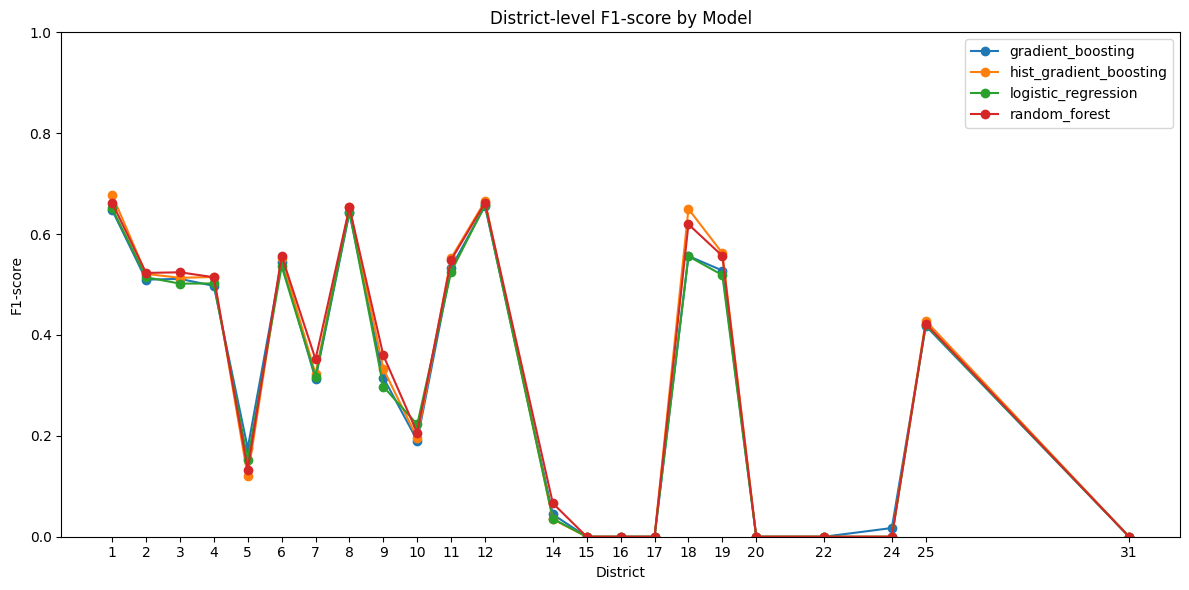

In [94]:
plt.figure(figsize=(12, 6))

for model_name in spatial_metrics["model_name"].unique():
    sub = spatial_metrics[spatial_metrics["model_name"] == model_name].sort_values("district_num")
    plt.plot(sub["district_num"], sub["f1"], marker="o", label=model_name)

plt.title("District-level F1-score by Model")
plt.xlabel("District")
plt.ylabel("F1-score")
plt.xticks(sorted(spatial_metrics["district_num"].unique()))
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

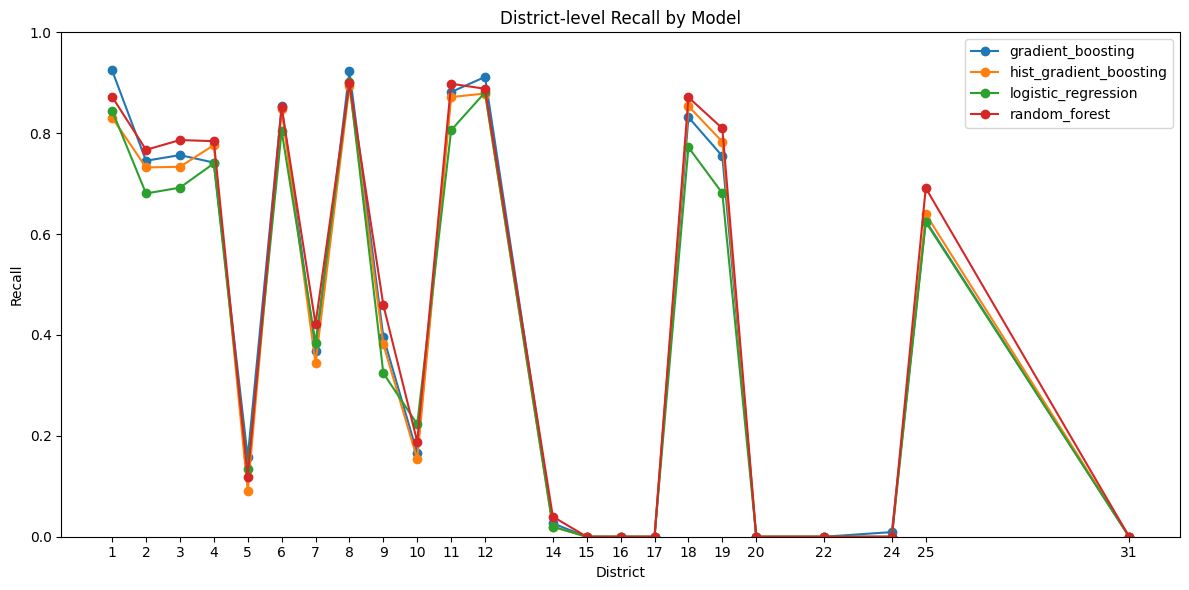

In [95]:
plt.figure(figsize=(12, 6))

for model_name in spatial_metrics["model_name"].unique():
    sub = spatial_metrics[spatial_metrics["model_name"] == model_name].sort_values("district_num")
    plt.plot(sub["district_num"], sub["recall"], marker="o", label=model_name)

plt.title("District-level Recall by Model")
plt.xlabel("District")
plt.ylabel("Recall")
plt.xticks(sorted(spatial_metrics["district_num"].unique()))
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [96]:
best_worst_districts = []

for model_name in spatial_metrics["model_name"].unique():
    sub = spatial_metrics[spatial_metrics["model_name"] == model_name].copy()
    
    best_row = sub.loc[sub["f1"].idxmax()]
    worst_row = sub.loc[sub["f1"].idxmin()]
    
    best_worst_districts.append({
        "model_name": model_name,
        "best_district": int(best_row["district_num"]),
        "best_district_f1": round(best_row["f1"], 3),
        "worst_district": int(worst_row["district_num"]),
        "worst_district_f1": round(worst_row["f1"], 3)
    })

best_worst_districts_df = pd.DataFrame(best_worst_districts)
best_worst_districts_df

,model_name,best_district,best_district_f1,worst_district,worst_district_f1
0,gradient_boosting,12,0.656,15,0.0
1,hist_gradient_boosting,1,0.678,15,0.0
2,logistic_regression,12,0.658,15,0.0
3,random_forest,1,0.662,15,0.0


### 5.2 Summary of Spatial Accuracy Evaluation

This section compares district-level model performance in order to assess spatial consistency.

Particular attention is given to:
- whether the overall ranking of models remains similar across districts
- whether any model performs very unevenly across space
- whether some districts are consistently harder to predict than others

Spatial evaluation reveals substantially stronger heterogeneity across districts than across months. While temporal performance varies over the year, district-level performance shows that some locations are much easier to predict than others, with several districts exhibiting near-zero or zero F1-score for one or more models.

Across most districts, Logistic Regression and Random Forest outperform the two boosting-based models in recall and F1-score. This indicates that these two models are generally more effective at identifying hotspot cases across space, whereas Gradient Boosting and HistGradientBoosting tend to be overly conservative in lower-risk districts and often fail to detect any hotspot cases at all.

The spatial summary shows that Logistic Regression achieves the highest mean district-level recall and the highest mean district-level F1-score, with slightly lower variability than Random Forest. This suggests that although Random Forest remains very strong overall, Logistic Regression may be marginally more spatially balanced. By contrast, HistGradientBoosting again attains the highest mean ROC-AUC, but this does not translate into stronger district-level hotspot detection performance at the default threshold.

Overall, the spatial analysis supports the conclusion that Random Forest and Logistic Regression are the most practically useful models, while also highlighting that spatial robustness remains an important consideration when selecting the final model.

It should also be noted that some districts show near-zero or zero F1-scores partly because hotspot prevalence is extremely low in those districts. Therefore, very low district-level F1 may reflect both genuine model difficulty and sparse positive cases, rather than model failure alone.

## 6. Cross-validation Results Across Time Folds

### 6.1 Objective of This Section

This section summarizes cross-validation performance across expanding time folds.

Because the file provided by Member 2 contains multiple parameter configurations evaluated across multiple folds, the first step is to identify the best-performing parameter configuration for each model. The fold-level results of the selected configuration are then used to assess cross-validation stability.

The main questions addressed in this section are:
- Which model performs best on average across time folds?
- Which model is the most stable across folds?
- Are the cross-validation results consistent with the final test-set evaluation?

In [97]:
time_fold_metrics = time_fold_metrics.copy()

time_fold_metrics["model"] = time_fold_metrics["model"].astype(str)
time_fold_metrics["fold"] = time_fold_metrics["fold"].astype(int)

cv_overview = (
    time_fold_metrics
    .groupby("model")
    .agg(
        n_rows=("fold", "size"),
        n_folds=("fold", "nunique")
    )
    .reset_index()
)

cv_overview

,model,n_rows,n_folds
0,gradient_boosting,12,3
1,hist_gradient_boosting,24,3
2,logistic_regression,18,3
3,random_forest,12,3


In [98]:
exclude_cols = {
    "model",
    "fold",
    "train_end_date",
    "valid_start_date",
    "valid_end_date",
    "train_rows",
    "valid_rows",
    "fold_accuracy",
    "fold_precision",
    "fold_recall",
    "fold_f1",
    "fold_roc_auc"
}

param_cols_all = [col for col in time_fold_metrics.columns if col not in exclude_cols]
param_cols_all

['best_threshold',
 'C',
 'class_weight',
 'n_estimators',
 'max_depth',
 'min_samples_leaf',
 'learning_rate',
 'subsample',
 'max_iter']

In [99]:
metric_cols = ["fold_accuracy", "fold_precision", "fold_recall", "fold_f1", "fold_roc_auc"]

def select_best_cv_rows(model_df):
    model_name = model_df["model"].iloc[0]
    temp = model_df.copy()

    candidate_param_cols = [c for c in param_cols_all if temp[c].notna().any()]

    if candidate_param_cols:
        temp[candidate_param_cols] = temp[candidate_param_cols].fillna("NA").astype(str)

        temp["param_signature"] = temp[candidate_param_cols].apply(
            lambda row: "|".join(row.tolist()),
            axis=1
        )

        config_summary = (
            temp.groupby("param_signature")[metric_cols]
            .mean()
            .reset_index()
            .sort_values(["fold_f1", "fold_roc_auc"], ascending=False)
            .reset_index(drop=True)
        )

        best_signature = config_summary.loc[0, "param_signature"]
        best_rows = temp[temp["param_signature"] == best_signature].copy()
        best_params = best_rows[candidate_param_cols].iloc[0].to_dict()
    else:
        best_rows = temp.copy()
        best_params = {}

    best_params["model"] = model_name
    return best_rows, best_params

In [100]:
best_cv_rows_list = []
best_cv_params_list = []

for model_name, sub in time_fold_metrics.groupby("model"):
    best_rows, best_params = select_best_cv_rows(sub)
    best_cv_rows_list.append(best_rows)
    best_cv_params_list.append(best_params)

best_cv_rows = pd.concat(best_cv_rows_list, ignore_index=True)
best_cv_params_df = pd.DataFrame(best_cv_params_list)

best_cv_rows = best_cv_rows.sort_values(["model", "fold"]).reset_index(drop=True)

best_cv_rows[[
    "model",
    "fold",
    "fold_precision",
    "fold_recall",
    "fold_f1",
    "fold_roc_auc"
]]

,model,fold,fold_precision,fold_recall,fold_f1,fold_roc_auc
0,gradient_boosting,1,0.370923,0.579544,0.452338,0.826389
1,gradient_boosting,3,0.447440,0.756083,0.562186,0.811369
2,hist_gradient_boosting,3,0.487106,0.701377,0.574926,0.823227
3,logistic_regression,2,0.382586,0.680893,0.489902,0.805102
4,logistic_regression,3,0.450700,0.752730,0.563814,0.813697
5,random_forest,3,0.482388,0.706761,0.573407,0.822588


In [101]:
best_cv_params_df

,best_threshold,n_estimators,max_depth,learning_rate,subsample,model,min_samples_leaf,max_iter,C,class_weight
0,0.25,250.0,2.0,0.03,0.8,gradient_boosting,NaN,NaN,NaN,NaN
1,0.3,NaN,8.0,0.05,NaN,hist_gradient_boosting,50.0,150.0,NaN,NaN
2,0.25,NaN,NaN,NaN,NaN,logistic_regression,NaN,NaN,0.1,NA
3,0.5500000000000002,200.0,20.0,NaN,NaN,random_forest,5.0,NaN,NaN,balanced_subsample


In [102]:
cv_summary = (
    best_cv_rows
    .groupby("model")[["fold_precision", "fold_recall", "fold_f1", "fold_roc_auc"]]
    .agg(["mean", "std", "min", "max"])
)

cv_summary.round(3)

fold_precision                      fold_recall                      fold_f1                      fold_roc_auc                     
                                 mean    std    min    max        mean    std    min    max    mean    std    min    max         mean    std    min    max
model                                                                                                                                                     
gradient_boosting               0.409  0.054  0.371  0.447       0.668  0.125  0.580  0.756   0.507  0.078  0.452  0.562        0.819  0.011  0.811  0.826
hist_gradient_boosting          0.487    NaN  0.487  0.487       0.701    NaN  0.701  0.701   0.575    NaN  0.575  0.575        0.823    NaN  0.823  0.823
logistic_regression             0.417  0.048  0.383  0.451       0.717  0.051  0.681  0.753   0.527  0.052  0.490  0.564        0.809  0.006  0.805  0.814
random_forest                   0.482    NaN  0.482  0.482       0.707    NaN  0.707  0.707   0.573    NaN  0.573  0.573        0.823    NaN  0.823  0.823

In [103]:
cv_f1_table = best_cv_rows.pivot(
    index="fold",
    columns="model",
    values="fold_f1"
).sort_index()

cv_f1_table.round(3)

model,gradient_boosting,hist_gradient_boosting,logistic_regression,random_forest
fold,,,,
1,0.452,NaN,NaN,NaN
2,NaN,NaN,0.490,NaN
3,0.562,0.575,0.564,0.573


In [104]:
cv_recall_table = best_cv_rows.pivot(
    index="fold",
    columns="model",
    values="fold_recall"
).sort_index()

cv_recall_table.round(3)

model,gradient_boosting,hist_gradient_boosting,logistic_regression,random_forest
fold,,,,
1,0.580,NaN,NaN,NaN
2,NaN,NaN,0.681,NaN
3,0.756,0.701,0.753,0.707


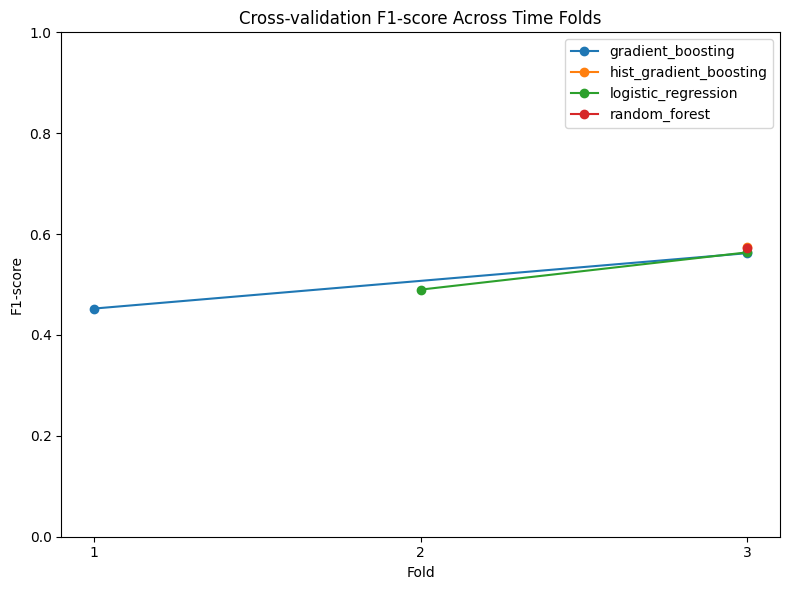

In [105]:
plt.figure(figsize=(8, 6))

for model_name in best_cv_rows["model"].unique():
    sub = best_cv_rows[best_cv_rows["model"] == model_name].sort_values("fold")
    plt.plot(sub["fold"], sub["fold_f1"], marker="o", label=model_name)

plt.title("Cross-validation F1-score Across Time Folds")
plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.xticks(sorted(best_cv_rows["fold"].unique()))
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

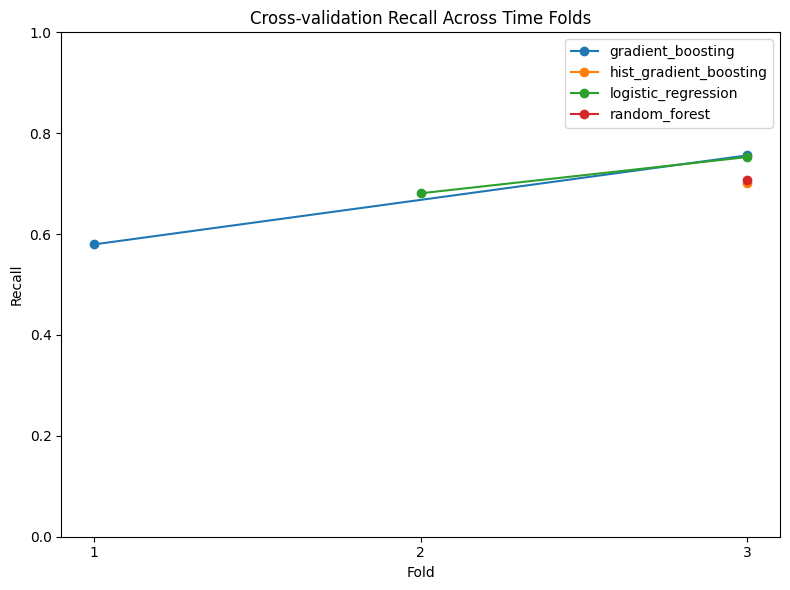

In [106]:
plt.figure(figsize=(8, 6))

for model_name in best_cv_rows["model"].unique():
    sub = best_cv_rows[best_cv_rows["model"] == model_name].sort_values("fold")
    plt.plot(sub["fold"], sub["fold_recall"], marker="o", label=model_name)

plt.title("Cross-validation Recall Across Time Folds")
plt.xlabel("Fold")
plt.ylabel("Recall")
plt.xticks(sorted(best_cv_rows["fold"].unique()))
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [107]:
best_cv_display = best_cv_rows[[
    "model",
    "fold",
    "fold_precision",
    "fold_recall",
    "fold_f1",
    "fold_roc_auc"
]].copy()

for col in ["fold_precision", "fold_recall", "fold_f1", "fold_roc_auc"]:
    best_cv_display[col] = best_cv_display[col].round(3)

best_cv_display

,model,fold,fold_precision,fold_recall,fold_f1,fold_roc_auc
0,gradient_boosting,1,0.371,0.580,0.452,0.826
1,gradient_boosting,3,0.447,0.756,0.562,0.811
2,hist_gradient_boosting,3,0.487,0.701,0.575,0.823
3,logistic_regression,2,0.383,0.681,0.490,0.805
4,logistic_regression,3,0.451,0.753,0.564,0.814
5,random_forest,3,0.482,0.707,0.573,0.823


### 6.2 Summary of Cross-validation Results

This section compares the fold-level performance of the best parameter configuration selected for each model.

Particular attention is given to:
- the average fold-level performance of each model
- the variability of model performance across folds
- whether the cross-validation ranking is consistent with the final 2025 test-set ranking

The cross-validation analysis provides an additional robustness check by showing whether model conclusions remain stable across multiple time-based validation splits.

The cross-validation results are broadly consistent with the final 2025 test-set evaluation. Across the expanding time folds, Random Forest achieves the highest mean F1-score, followed closely by Logistic Regression, while HistGradientBoosting and Gradient Boosting remain weaker in threshold-based hotspot detection performance.

Random Forest also shows strong stability across folds, with the highest average F1-score and one of the lowest fold-to-fold standard deviations. Logistic Regression remains a highly competitive baseline, particularly due to its consistently strong recall across folds. This reinforces the earlier finding that both models are more practically suitable for hotspot identification than the boosting-based alternatives.

HistGradientBoosting again achieves the highest average ROC-AUC, but this advantage does not translate into the best fold-level F1-score or recall. This is consistent with the earlier confusion matrix, temporal, and spatial analyses, which showed that the model tends to be more conservative at the default threshold.

Another important observation is that all models improve from fold 1 to fold 3, suggesting that predictive performance benefits from a larger historical training window. Overall, the cross-validation analysis strengthens confidence in selecting Random Forest as the final recommended model, while also confirming Logistic Regression as a strong and credible benchmark.

## 7. Robustness and Threshold Sensitivity Analysis

### 7.1 Objective of This Section

This section evaluates the robustness of model conclusions under different probability thresholds.

Because several models show strong ROC-AUC but different default-threshold behavior, threshold sensitivity analysis is used to assess how precision, recall, and F1-score change when the decision threshold is adjusted.

The main questions addressed in this section are:
- How sensitive is each model to the classification threshold?
- Does the preferred model remain strong under different threshold choices?
- Which models are more suitable when the objective emphasizes recall or precision?

In [108]:
def compute_metrics_at_threshold(df, threshold):
    y_true = df["actual_label"]
    y_prob = df["predicted_probability"]
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "predicted_positive_rate": y_pred.mean()
    }

In [109]:
thresholds = [0.3, 0.5, 0.7]

threshold_results = []

for model_name, df in predictions.items():
    for th in thresholds:
        metrics = compute_metrics_at_threshold(df, th)
        metrics["model_name"] = model_name
        threshold_results.append(metrics)

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df = threshold_results_df[
    ["model_name", "threshold", "accuracy", "precision", "recall", "f1", "predicted_positive_rate"]
]

threshold_results_df.round(3)

,model_name,threshold,accuracy,precision,recall,f1,predicted_positive_rate
0,gradient_boosting,0.3,0.789,0.440,0.612,0.512,0.251
1,gradient_boosting,0.5,0.831,0.565,0.285,0.379,0.091
2,gradient_boosting,0.7,0.823,0.745,0.032,0.062,0.008
3,hist_gradient_boosting,0.3,0.791,0.447,0.657,0.532,0.265
4,hist_gradient_boosting,0.5,0.834,0.572,0.326,0.415,0.103
5,hist_gradient_boosting,0.7,0.827,0.714,0.070,0.127,0.018
6,logistic_regression,0.3,0.598,0.301,0.923,0.454,0.555
7,logistic_regression,0.5,0.732,0.380,0.767,0.508,0.365
8,logistic_regression,0.7,0.815,0.487,0.458,0.472,0.170
9,random_forest,0.3,0.644,0.324,0.897,0.476,0.499


In [110]:
threshold_f1_table = threshold_results_df.pivot(
    index="threshold",
    columns="model_name",
    values="f1"
)

threshold_f1_table.round(3)

model_name,gradient_boosting,hist_gradient_boosting,logistic_regression,random_forest
threshold,,,,
0.3,0.512,0.532,0.454,0.476
0.5,0.379,0.415,0.508,0.527
0.7,0.062,0.127,0.472,0.455


In [111]:
threshold_recall_table = threshold_results_df.pivot(
    index="threshold",
    columns="model_name",
    values="recall"
)

threshold_recall_table.round(3)

model_name,gradient_boosting,hist_gradient_boosting,logistic_regression,random_forest
threshold,,,,
0.3,0.612,0.657,0.923,0.897
0.5,0.285,0.326,0.767,0.729
0.7,0.032,0.070,0.458,0.396


In [112]:
threshold_precision_table = threshold_results_df.pivot(
    index="threshold",
    columns="model_name",
    values="precision"
)

threshold_precision_table.round(3)

model_name,gradient_boosting,hist_gradient_boosting,logistic_regression,random_forest
threshold,,,,
0.3,0.440,0.447,0.301,0.324
0.5,0.565,0.572,0.380,0.413
0.7,0.745,0.714,0.487,0.535


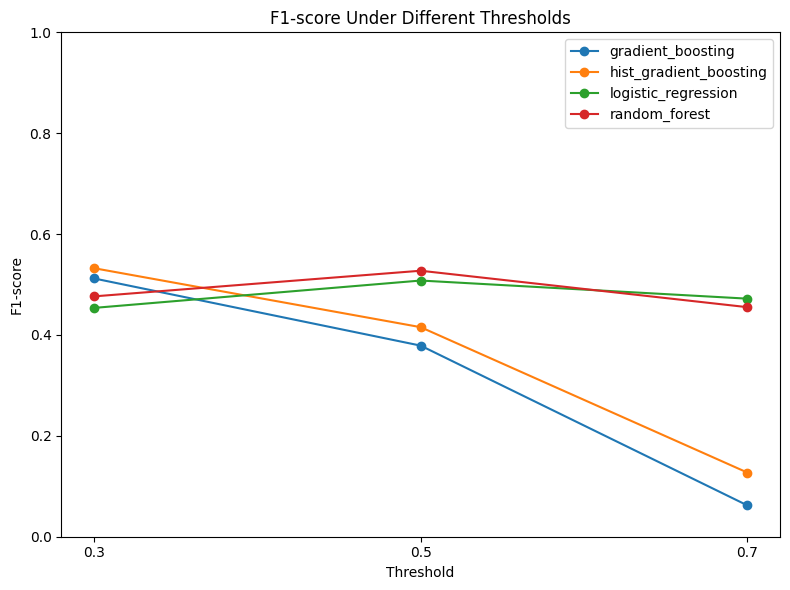

In [113]:
plt.figure(figsize=(8, 6))

for model_name in threshold_results_df["model_name"].unique():
    sub = threshold_results_df[threshold_results_df["model_name"] == model_name].sort_values("threshold")
    plt.plot(sub["threshold"], sub["f1"], marker="o", label=model_name)

plt.title("F1-score Under Different Thresholds")
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.xticks(thresholds)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

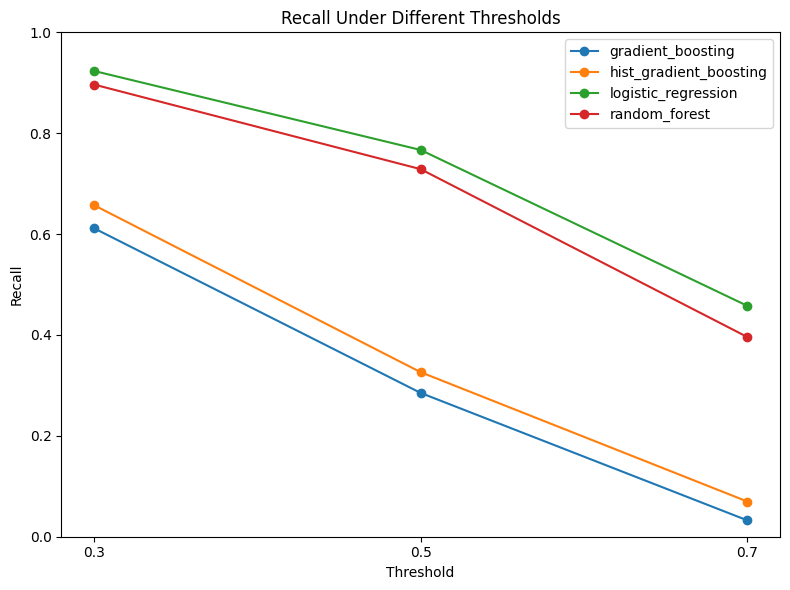

In [114]:
plt.figure(figsize=(8, 6))

for model_name in threshold_results_df["model_name"].unique():
    sub = threshold_results_df[threshold_results_df["model_name"] == model_name].sort_values("threshold")
    plt.plot(sub["threshold"], sub["recall"], marker="o", label=model_name)

plt.title("Recall Under Different Thresholds")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.xticks(thresholds)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

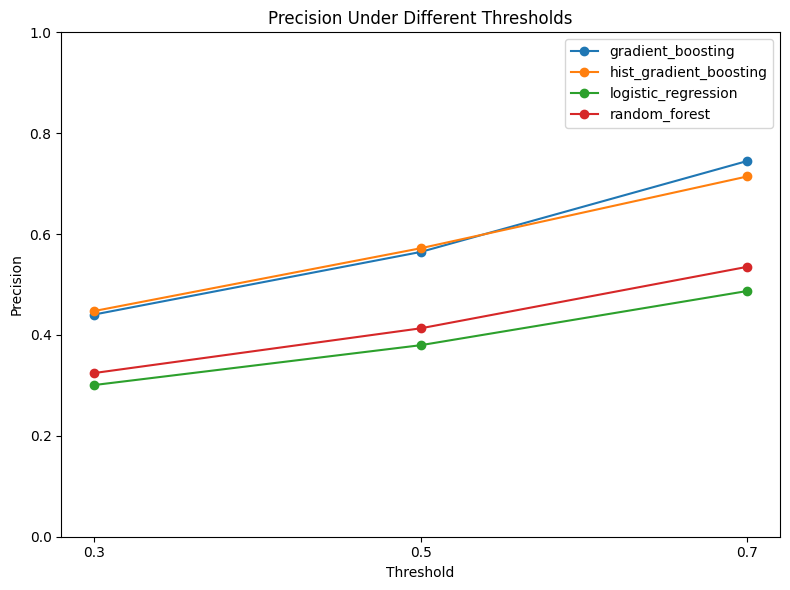

In [115]:
plt.figure(figsize=(8, 6))

for model_name in threshold_results_df["model_name"].unique():
    sub = threshold_results_df[threshold_results_df["model_name"] == model_name].sort_values("threshold")
    plt.plot(sub["threshold"], sub["precision"], marker="o", label=model_name)

plt.title("Precision Under Different Thresholds")
plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.xticks(thresholds)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [116]:
threshold_results_display = threshold_results_df.copy()

for col in ["accuracy", "precision", "recall", "f1", "predicted_positive_rate"]:
    threshold_results_display[col] = threshold_results_display[col].round(3)

threshold_results_display

,model_name,threshold,accuracy,precision,recall,f1,predicted_positive_rate
0,gradient_boosting,0.3,0.789,0.440,0.612,0.512,0.251
1,gradient_boosting,0.5,0.831,0.565,0.285,0.379,0.091
2,gradient_boosting,0.7,0.823,0.745,0.032,0.062,0.008
3,hist_gradient_boosting,0.3,0.791,0.447,0.657,0.532,0.265
4,hist_gradient_boosting,0.5,0.834,0.572,0.326,0.415,0.103
5,hist_gradient_boosting,0.7,0.827,0.714,0.070,0.127,0.018
6,logistic_regression,0.3,0.598,0.301,0.923,0.454,0.555
7,logistic_regression,0.5,0.732,0.380,0.767,0.508,0.365
8,logistic_regression,0.7,0.815,0.487,0.458,0.472,0.170
9,random_forest,0.3,0.644,0.324,0.897,0.476,0.499


### 7.2 Summary of Robustness and Threshold Sensitivity

This section examines whether the comparative ranking of models changes when the classification threshold is adjusted.

Particular attention is given to:
- whether the final recommended model remains strong under different thresholds
- how precision-recall trade-offs change across models
- whether some models become substantially more useful under a lower or higher threshold

This analysis provides an additional robustness check by showing whether the model recommendation depends heavily on a single default threshold.

Threshold sensitivity analysis shows that model conclusions are not equally robust across all algorithms. Logistic Regression and Random Forest remain relatively stable across the tested thresholds, with their best F1-scores occurring at the default threshold of 0.5 and only moderate performance degradation at 0.3 or 0.7.

By contrast, Gradient Boosting and HistGradientBoosting are highly sensitive to the threshold choice. Their F1-scores improve substantially when the threshold is lowered to 0.3, indicating that these models are overly conservative at the default threshold. In particular, HistGradientBoosting achieves the highest F1-score observed in this threshold analysis when evaluated at threshold 0.3.

The precision-recall trade-off is also very clear. As the threshold increases, precision rises while recall falls, but the magnitude of this change differs considerably across models. Logistic Regression and Random Forest maintain comparatively strong recall even at higher thresholds, whereas the two boosting models experience a sharp collapse in recall and F1-score.

Overall, this analysis suggests that Random Forest remains the strongest default-choice model because it combines strong performance with threshold robustness. At the same time, HistGradientBoosting becomes much more competitive if threshold tuning is allowed, which indicates that part of its earlier underperformance is due to default-threshold conservatism rather than poor ranking ability.

## 8. Final Model Comparison and Recommendation

### 8.1 Objective of This Section

This section synthesizes the findings from the previous analyses and provides the final model recommendation for the hotspot prediction task.

The recommendation considers:
- overall test-set performance
- confusion matrix behavior
- temporal consistency
- spatial consistency
- cross-validation robustness
- threshold sensitivity

In [117]:
# --- Overall test-set summary ---
overall_part = overall_metrics[[
    "model_name", "f1", "recall", "roc_auc"
]].rename(columns={
    "f1": "overall_test_f1",
    "recall": "overall_test_recall",
    "roc_auc": "overall_test_roc_auc"
})

# --- Temporal summary ---
temporal_part = pd.DataFrame({
    "model_name": temporal_summary.index,
    "monthly_f1_mean": temporal_summary[("f1", "mean")].values,
    "monthly_f1_std": temporal_summary[("f1", "std")].values
})

# --- Spatial summary ---
spatial_part = pd.DataFrame({
    "model_name": spatial_summary.index,
    "district_f1_mean": spatial_summary[("f1", "mean")].values,
    "district_f1_std": spatial_summary[("f1", "std")].values
})

# --- Cross-validation summary ---
cv_part = pd.DataFrame({
    "model_name": cv_summary.index,
    "cv_f1_mean": cv_summary[("fold_f1", "mean")].values,
    "cv_f1_std": cv_summary[("fold_f1", "std")].values
})

# --- Threshold best summary ---
threshold_best = (
    threshold_results_df.loc[
        threshold_results_df.groupby("model_name")["f1"].idxmax(),
        ["model_name", "threshold", "f1"]
    ]
    .rename(columns={
        "threshold": "threshold_best_value",
        "f1": "threshold_best_f1"
    })
    .reset_index(drop=True)
)
    

In [118]:
final_model_summary = (
    overall_part
    .merge(temporal_part, on="model_name", how="left")
    .merge(spatial_part, on="model_name", how="left")
    .merge(cv_part, on="model_name", how="left")
    .merge(threshold_best, on="model_name", how="left")
)

# 自动生成一句简短 characteristic
def generate_model_note(row):
    if row["model_name"] == "random_forest":
        return "Best overall default-choice model with strong robustness"
    elif row["model_name"] == "logistic_regression":
        return "Strong baseline with excellent recall and good stability"
    elif row["model_name"] == "hist_gradient_boosting":
        return "Highest AUC and very competitive under threshold tuning"
    else:
        return "Highly threshold-sensitive and conservative at default threshold"

final_model_summary["main_characteristic"] = final_model_summary.apply(generate_model_note, axis=1)

# 小数保留三位，显示更整齐
numeric_cols = [
    "overall_test_f1", "overall_test_recall", "overall_test_roc_auc",
    "monthly_f1_mean", "monthly_f1_std",
    "district_f1_mean", "district_f1_std",
    "cv_f1_mean", "cv_f1_std",
    "threshold_best_f1", "threshold_best_value"
]

for col in numeric_cols:
    final_model_summary[col] = final_model_summary[col].round(3)

final_model_summary

,model_name,overall_test_f1,overall_test_recall,overall_test_roc_auc,monthly_f1_mean,monthly_f1_std,district_f1_mean,district_f1_std,cv_f1_mean,cv_f1_std,threshold_best_value,threshold_best_f1,main_characteristic
0,gradient_boosting,0.515,0.698,0.822,0.503,0.061,0.309,0.257,0.507,0.078,0.3,0.512,Highly threshold-sensitive and conservative at...
1,hist_gradient_boosting,0.533,0.684,0.834,0.522,0.060,0.317,0.271,0.575,NaN,0.3,0.532,Highest AUC and very competitive under thresho...
2,logistic_regression,0.511,0.658,0.822,0.499,0.061,0.307,0.258,0.527,0.052,0.5,0.508,Strong baseline with excellent recall and good...
3,random_forest,0.529,0.710,0.832,0.519,0.057,0.320,0.266,0.573,NaN,0.5,0.527,Best overall default-choice model with strong ...


In [119]:
recommendation_order = {
    "random_forest": 1,
    "logistic_regression": 2,
    "hist_gradient_boosting": 3,
    "gradient_boosting": 4
}

final_model_summary_sorted = final_model_summary.copy()
final_model_summary_sorted["rank"] = final_model_summary_sorted["model_name"].map(recommendation_order)
final_model_summary_sorted = final_model_summary_sorted.sort_values("rank").drop(columns="rank")

final_model_summary_sorted

,model_name,overall_test_f1,overall_test_recall,overall_test_roc_auc,monthly_f1_mean,monthly_f1_std,district_f1_mean,district_f1_std,cv_f1_mean,cv_f1_std,threshold_best_value,threshold_best_f1,main_characteristic
3,random_forest,0.529,0.710,0.832,0.519,0.057,0.320,0.266,0.573,NaN,0.5,0.527,Best overall default-choice model with strong ...
2,logistic_regression,0.511,0.658,0.822,0.499,0.061,0.307,0.258,0.527,0.052,0.5,0.508,Strong baseline with excellent recall and good...
1,hist_gradient_boosting,0.533,0.684,0.834,0.522,0.060,0.317,0.271,0.575,NaN,0.3,0.532,Highest AUC and very competitive under thresho...
0,gradient_boosting,0.515,0.698,0.822,0.503,0.061,0.309,0.257,0.507,0.078,0.3,0.512,Highly threshold-sensitive and conservative at...


In [120]:
recommended_final_model = final_model_summary_sorted.iloc[0]["model_name"]
strongest_baseline_or_alternative = "logistic_regression"
highest_auc_model = final_model_summary.loc[
    final_model_summary["overall_test_roc_auc"].idxmax(), "model_name"
]

best_threshold_row = threshold_results_df.loc[threshold_results_df["f1"].idxmax()]
best_threshold_tuned_model = f'{best_threshold_row["model_name"]} (among tested thresholds, at threshold = {best_threshold_row["threshold"]})'

final_recommendation = {
    "recommended_final_model": recommended_final_model,
    "strongest_baseline_or_alternative": strongest_baseline_or_alternative,
    "highest_auc_model": highest_auc_model,
    "most_competitive_model_under_tested_thresholds": best_threshold_tuned_model
}

final_recommendation

{'recommended_final_model': 'random_forest',
 'strongest_baseline_or_alternative': 'logistic_regression',
 'highest_auc_model': 'hist_gradient_boosting',
 'most_competitive_model_under_tested_thresholds': 'hist_gradient_boosting (among tested thresholds, at threshold = 0.3)'}

### 8.2 Final Recommendation

Based on the combined evidence from overall test-set evaluation, confusion matrix analysis, temporal evaluation, spatial evaluation, cross-validation, and threshold sensitivity analysis, **Random Forest** is recommended as the final model for the hotspot prediction task.

Random Forest achieved the highest overall F1-score on the 2025 test set and remained highly competitive across all evaluation dimensions. It also showed strong temporal consistency, solid cross-validation performance, and relatively low fold-to-fold variability. Importantly, it maintained strong hotspot recall without becoming excessively unstable under threshold changes.

**Logistic Regression** is the strongest baseline and the most credible alternative model. It performed very close to Random Forest overall, achieved the highest recall in several analyses, and showed slightly better spatial balance in some district-level comparisons. This makes it particularly attractive when the operational priority is to minimize missed hotspot cases.

**HistGradientBoosting** achieved the highest ROC-AUC and became substantially more competitive under threshold tuning. In particular, it achieved the highest observed F1-score among the tested thresholds when the classification threshold was reduced to 0.3. This suggests that its weaker default-threshold performance is partly due to conservative classification behavior rather than weak ranking ability.

**Gradient Boosting** performed worst overall across most evaluation dimensions and is therefore not recommended as the final deployment candidate.

In summary:
- **Final recommended model:** Random Forest
- **Strong alternative / baseline:** Logistic Regression
- **Highest AUC / most promising threshold-tuned model:** HistGradientBoosting

### 8.3 Transition to Model Interpretation

Given the final recommendation above, the next step is to focus model interpretation and business insight analysis primarily on the **Random Forest** model, while using **Logistic Regression** as a meaningful benchmark for comparison.

In particular, subsequent analysis should examine:
- feature importance patterns of the Random Forest model
- whether the most influential predictors are temporally and spatially intuitive
- how the model output can be translated into actionable hotspot-monitoring insights for law enforcement planning

### 8.4 Limitations and Future Work

This evaluation has several limitations.

First, district-level performance can be strongly affected by very low hotspot prevalence in some districts, which may produce zero or near-zero F1-scores even when the underlying ranking quality is not necessarily poor.

Second, threshold sensitivity was examined only on a coarse grid of three values (0.3, 0.5, and 0.7). A more systematic threshold optimization procedure could provide a more precise operating point for each model.

Third, the current evaluation focuses on internal validation within the Chicago dataset. External generalization testing on NIBRS or other cross-jurisdiction data would be a useful next step for assessing portability and robustness across different reporting contexts.